<a href="https://colab.research.google.com/github/ayukartikaa0301/kmeans-tiktok-segmentation/blob/main/Ayu_Kartika_Skripsi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# ============================================================================
# PENERAPAN K-MEANS CLUSTERING UNTUK SEGMENTASI PERFORMA TIKTOK
# Studi Kasus: Perusahaan Kecap Djoe-Hoa
# Penulis: Ayu Kartika (22166020)
# ============================================================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import warnings
warnings.filterwarnings('ignore')

# Set style untuk visualisasi
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# ============================================================================
# 1. PENGUMPULAN & INTEGRASI DATA
# ============================================================================
print("="*80)
print("1. MEMUAT DAN MENGINTEGRASIKAN DATA")
print("="*80)

# Load dataset
df1 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Overview_April-Des2025.csv')
df2 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Overview_Jan-April2026.csv')
df_viewers = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Viewers.csv')

print(f"✓ Dataset 1 (Apr-Des 2025): {df1.shape[0]} baris")
print(f"✓ Dataset 2 (Jan-Apr 2026): {df2.shape[0]} baris")
print(f"✓ Dataset Viewers: {df_viewers.shape[0]} baris")

# Gabungkan df1 dan df2
df = pd.concat([df1, df2], ignore_index=True)

# Hapus duplikasi tanggal (misal: 31 Des muncul 2x)
df = df.drop_duplicates(subset='Date', keep='first')

# Urutkan berdasarkan tanggal
df['Date'] = pd.to_datetime(df['Date'], format='%B %d')
df = df.sort_values('Date').reset_index(drop=True)

print(f"\n✓ Total data setelah integrasi: {df.shape[0]} hari")
print(f"✓ Periode: {df['Date'].min()} s/d {df['Date'].max()}")

1. MEMUAT DAN MENGINTEGRASIKAN DATA
✓ Dataset 1 (Apr-Des 2025): 262 baris
✓ Dataset 2 (Jan-Apr 2026): 102 baris
✓ Dataset Viewers: 60 baris

✓ Total data setelah integrasi: 363 hari
✓ Periode: 1900-01-01 00:00:00 s/d 1900-12-31 00:00:00


In [7]:
# ============================================================================
# 2. DATA CLEANING
# ============================================================================
print("\n" + "="*80)
print("2. DATA CLEANING")
print("="*80)

# Cek nilai negatif
print(f"Nilai negatif pada Comments: {(df['Comments'] < 0).sum()}")
print(f"Nilai negatif pada Shares: {(df['Shares'] < 0).sum()}")

# Ganti nilai negatif dengan 0
df['Comments'] = df['Comments'].apply(lambda x: 0 if x < 0 else x)
df['Shares'] = df['Shares'].apply(lambda x: 0 if x < 0 else x)

# Cek missing values
print(f"\nMissing values per kolom:")
print(df.isnull().sum())

# Handle undefined di Viewers.csv (jika ada)
if 'Total Viewers' in df_viewers.columns:
    df_viewers['Total Viewers'] = pd.to_numeric(df_viewers['Total Viewers'], errors='coerce')
    df_viewers = df_viewers.dropna(subset=['Total Viewers'])

print(f"✓ Data cleaning selesai")


2. DATA CLEANING
Nilai negatif pada Comments: 3
Nilai negatif pada Shares: 0

Missing values per kolom:
Date             0
Video Views      0
Profile Views    0
Likes            0
Comments         0
Shares           0
dtype: int64
✓ Data cleaning selesai


In [8]:
# ============================================================================
# 3. FEATURE ENGINEERING
# ============================================================================
print("\n" + "="*80)
print("3. FEATURE ENGINEERING")
print("="*80)

# Hitung Engagement Rate
df['Engagement_Rate'] = ((df['Likes'] + df['Comments'] + df['Shares']) / df['Video Views']) * 100

# Statistik deskriptif Engagement Rate
print(f"\nStatistik Engagement Rate:")
print(df['Engagement_Rate'].describe())

# Jika ada data viewers, hitung New_Viewers_Ratio
if 'Total Viewers' in df_viewers.columns and 'New Viewers' in df_viewers.columns:
    df_viewers['New_Viewers_Ratio'] = df_viewers['New Viewers'] / df_viewers['Total Viewers']
    print(f"✓ New_Viewers_Ratio berhasil dihitung")

# Buat fitur tambahan: Total_Interactions
df['Total_Interactions'] = df['Likes'] + df['Comments'] + df['Shares']

print(f"✓ Feature engineering selesai")
print(f"  - Engagement_Rate: rata-rata {df['Engagement_Rate'].mean():.2f}%")
print(f"  - Total_Interactions: rata-rata {df['Total_Interactions'].mean():.2f}")


3. FEATURE ENGINEERING

Statistik Engagement Rate:
count    363.000000
mean       0.366074
std        0.474653
min        0.000000
25%        0.131378
50%        0.247804
75%        0.404965
max        3.546753
Name: Engagement_Rate, dtype: float64
✓ New_Viewers_Ratio berhasil dihitung
✓ Feature engineering selesai
  - Engagement_Rate: rata-rata 0.37%
  - Total_Interactions: rata-rata 16.39


In [9]:
# ============================================================================
# 4. SELEKSI FITUR UNTUK CLUSTERING
# ============================================================================
print("\n" + "="*80)
print("4. SELEKSI FITUR UNTUK CLUSTERING")
print("="*80)

# Fitur yang akan digunakan untuk clustering
features = ['Video Views', 'Likes', 'Comments', 'Shares', 'Engagement_Rate']

# Buat dataframe untuk clustering
df_cluster = df[features].copy()

print(f"Fitur yang digunakan: {features}")
print(f"\nStatistik deskriptif sebelum scaling:")
print(df_cluster.describe())


4. SELEKSI FITUR UNTUK CLUSTERING
Fitur yang digunakan: ['Video Views', 'Likes', 'Comments', 'Shares', 'Engagement_Rate']

Statistik deskriptif sebelum scaling:
        Video Views       Likes    Comments      Shares  Engagement_Rate
count    363.000000  363.000000  363.000000  363.000000       363.000000
mean    4451.220386   14.776860    0.853994    0.757576         0.366074
std     3549.697846   22.781749    1.423230    1.407033         0.474653
min       11.000000    0.000000    0.000000    0.000000         0.000000
25%     2688.000000    3.000000    0.000000    0.000000         0.131378
50%     3517.000000    8.000000    0.000000    0.000000         0.247804
75%     4717.500000   17.000000    1.000000    1.000000         0.404965
max    31118.000000  173.000000    9.000000   12.000000         3.546753


In [10]:
# ============================================================================
# 5. NORMALISASI/SCALING
# ============================================================================
print("\n" + "="*80)
print("5. NORMALISASI DATA (STANDARD SCALER)")
print("="*80)

# StandardScaler
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_cluster),
                         columns=features,
                         index=df_cluster.index)

print(f"✓ Data berhasil dinormalisasi")
print(f"  Mean setelah scaling: {df_scaled.mean().mean():.6f} (mendekati 0)")
print(f"  Std setelah scaling: {df_scaled.std().mean():.6f} (mendekati 1)")


5. NORMALISASI DATA (STANDARD SCALER)
✓ Data berhasil dinormalisasi
  Mean setelah scaling: 0.000000 (mendekati 0)
  Std setelah scaling: 1.001380 (mendekati 1)



6. PENENTUAN JUMLAH KLASTER OPTIMAL

Hasil Evaluasi untuk Berbagai Nilai k:
--------------------------------------------------------------------------------
k     WCSS            Silhouette      DBI             CHI            
--------------------------------------------------------------------------------
2     1329.48         0.7424          0.3120          131.83         
3     941.88          0.5330          1.0319          166.86         
4     770.32          0.5014          1.0492          162.29         
5     637.83          0.3807          1.0097          165.18         
6     521.65          0.4338          0.8923          177.03         

✓ k optimal berdasarkan Silhouette Score: k = 2 (Score: 0.7424)

7. VISUALISASI HASIL EVALUASI


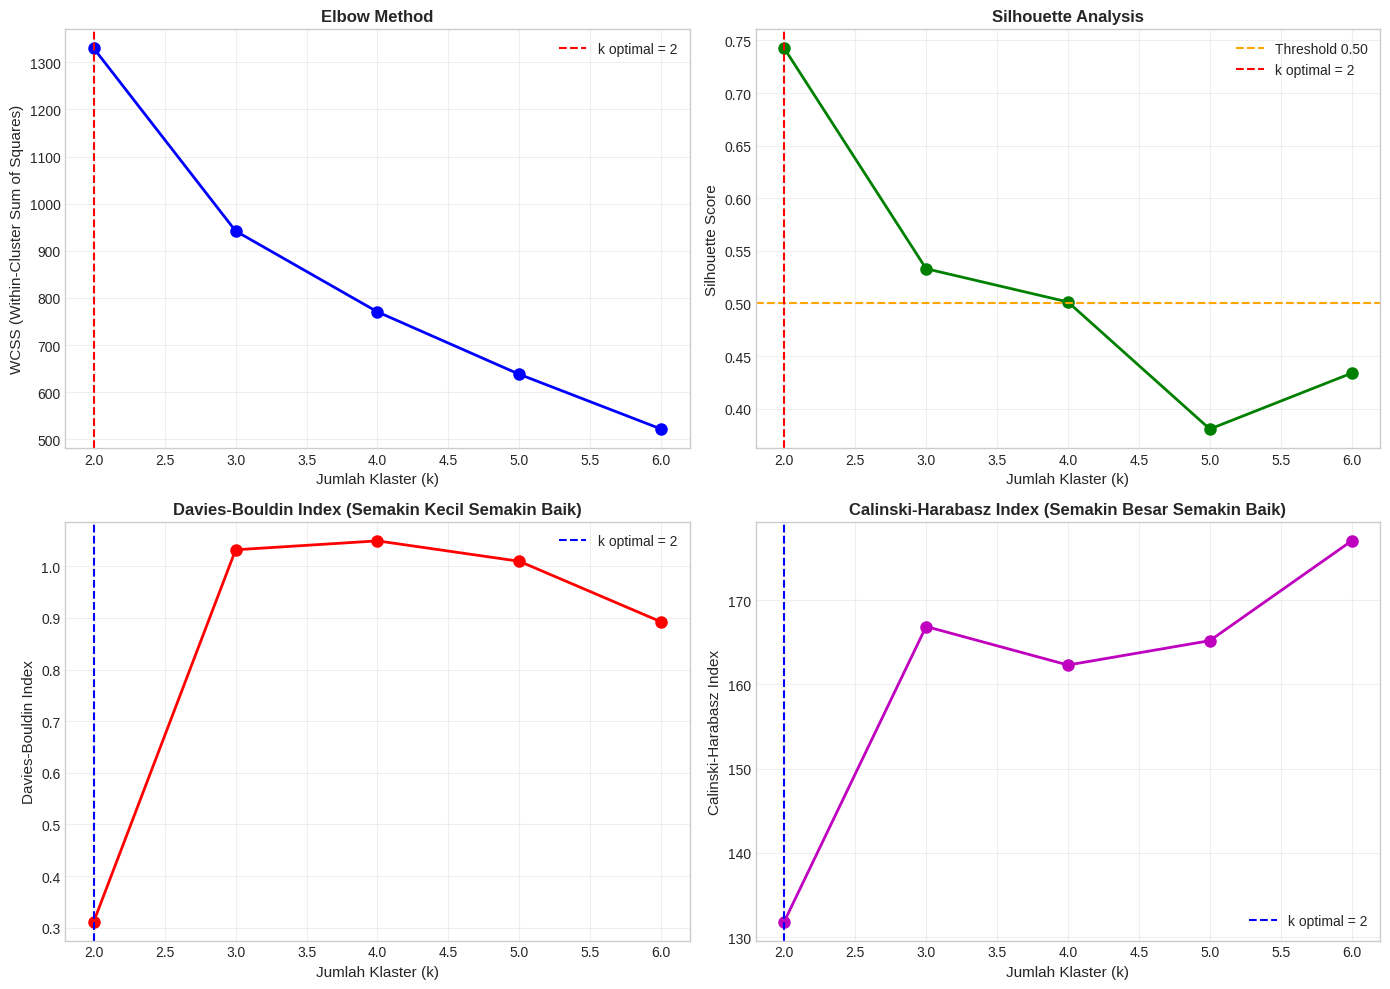

In [11]:
# ============================================================================
# 6. PENENTUAN K OPTIMAL - ELBOW METHOD & SILHOUETTE ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("6. PENENTUAN JUMLAH KLASTER OPTIMAL")
print("="*80)

# Range k yang akan diuji
k_range = range(2, 7)

# Lists untuk menyimpan hasil evaluasi
wcss = []
silhouette_scores = []
davies_bouldin_scores = []
calinski_harabasz_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_scaled)

    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_scaled, labels))
    davies_bouldin_scores.append(davies_bouldin_score(df_scaled, labels))
    calinski_harabasz_scores.append(calinski_harabasz_score(df_scaled, labels))

# Tampilkan hasil evaluasi
print("\nHasil Evaluasi untuk Berbagai Nilai k:")
print("-" * 80)
print(f"{'k':<5} {'WCSS':<15} {'Silhouette':<15} {'DBI':<15} {'CHI':<15}")
print("-" * 80)
for i, k in enumerate(k_range):
    print(f"{k:<5} {wcss[i]:<15.2f} {silhouette_scores[i]:<15.4f} {davies_bouldin_scores[i]:<15.4f} {calinski_harabasz_scores[i]:<15.2f}")

# Tentukan k optimal berdasarkan Silhouette Score tertinggi
k_optimal_idx = np.argmax(silhouette_scores)
k_optimal = list(k_range)[k_optimal_idx]
print(f"\n✓ k optimal berdasarkan Silhouette Score: k = {k_optimal} (Score: {silhouette_scores[k_optimal_idx]:.4f})")

# ============================================================================
# 7. VISUALISASI ELBOW METHOD & SILHOUETTE
# ============================================================================
print("\n" + "="*80)
print("7. VISUALISASI HASIL EVALUASI")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Elbow Method
axes[0, 0].plot(k_range, wcss, 'bo-', linewidth=2, markersize=8)
axes[0, 0].axvline(x=k_optimal, color='r', linestyle='--', label=f'k optimal = {k_optimal}')
axes[0, 0].set_xlabel('Jumlah Klaster (k)', fontsize=11)
axes[0, 0].set_ylabel('WCSS (Within-Cluster Sum of Squares)', fontsize=11)
axes[0, 0].set_title('Elbow Method', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Silhouette Score
axes[0, 1].plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[0, 1].axhline(y=0.5, color='orange', linestyle='--', label='Threshold 0.50')
axes[0, 1].axvline(x=k_optimal, color='r', linestyle='--', label=f'k optimal = {k_optimal}')
axes[0, 1].set_xlabel('Jumlah Klaster (k)', fontsize=11)
axes[0, 1].set_ylabel('Silhouette Score', fontsize=11)
axes[0, 1].set_title('Silhouette Analysis', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Davies-Bouldin Index
axes[1, 0].plot(k_range, davies_bouldin_scores, 'ro-', linewidth=2, markersize=8)
axes[1, 0].axvline(x=k_optimal, color='b', linestyle='--', label=f'k optimal = {k_optimal}')
axes[1, 0].set_xlabel('Jumlah Klaster (k)', fontsize=11)
axes[1, 0].set_ylabel('Davies-Bouldin Index', fontsize=11)
axes[1, 0].set_title('Davies-Bouldin Index (Semakin Kecil Semakin Baik)', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Calinski-Harabasz Index
axes[1, 1].plot(k_range, calinski_harabasz_scores, 'mo-', linewidth=2, markersize=8)
axes[1, 1].axvline(x=k_optimal, color='b', linestyle='--', label=f'k optimal = {k_optimal}')
axes[1, 1].set_xlabel('Jumlah Klaster (k)', fontsize=11)
axes[1, 1].set_ylabel('Calinski-Harabasz Index', fontsize=11)
axes[1, 1].set_title('Calinski-Harabasz Index (Semakin Besar Semakin Baik)', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('evaluasi_k_optimal.png', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
# ============================================================================
# 8. EKSEKUSI K-MEANS DENGAN K OPTIMAL
# ============================================================================
print("\n" + "="*80)
print("8. EKSEKUSI ALGORITMA K-MEANS CLUSTERING")
print("="*80)

# Inisialisasi dan fit K-Means dengan k optimal
kmeans_final = KMeans(n_clusters=k_optimal,
                      init='k-means++',
                      n_init=10,
                      max_iter=300,
                      random_state=42)

# Fit dan predict
df['Cluster'] = kmeans_final.fit_predict(df_scaled)

# Tampilkan distribusi klaster
print(f"\nDistribusi Klaster:")
print("-" * 40)
cluster_counts = df['Cluster'].value_counts().sort_index()
for cluster, count in cluster_counts.items():
    percentage = (count / len(df)) * 100
    print(f"Klaster {cluster}: {count} hari ({percentage:.1f}%)")


8. EKSEKUSI ALGORITMA K-MEANS CLUSTERING

Distribusi Klaster:
----------------------------------------
Klaster 0: 356 hari (98.1%)
Klaster 1: 7 hari (1.9%)


In [13]:
# ============================================================================
# 9. EVALUASI KUALITAS KLASTER
# ============================================================================
print("\n" + "="*80)
print("9. EVALUASI KUALITAS KLASTER")
print("="*80)

# Hitung metrik evaluasi
final_silhouette = silhouette_score(df_scaled, df['Cluster'])
final_davies_bouldin = davies_bouldin_score(df_scaled, df['Cluster'])
final_calinski_harabasz = calinski_harabasz_score(df_scaled, df['Cluster'])

print(f"Silhouette Score: {final_silhouette:.4f}")
print(f"Davies-Bouldin Index: {final_davies_bouldin:.4f}")
print(f"Calinski-Harabasz Index: {final_calinski_harabasz:.2f}")

# Interpretasi
print("\nInterpretasi:")
if final_silhouette >= 0.50:
    print(f"✓ Silhouette Score ≥ 0.50 → Struktur klaster KUAT dan JELAS")
elif final_silhouette >= 0.25:
    print(f"△ Silhouette Score 0.25-0.50 → Struktur klaster CUKUP, ada tumpang tindih")
else:
    print(f"✗ Silhouette Score < 0.25 → Struktur klaster LEMAH")


9. EVALUASI KUALITAS KLASTER
Silhouette Score: 0.7424
Davies-Bouldin Index: 0.3120
Calinski-Harabasz Index: 131.83

Interpretasi:
✓ Silhouette Score ≥ 0.50 → Struktur klaster KUAT dan JELAS


In [14]:
# ============================================================================
# 10. ANALISIS PROFIL KLASTER
# ============================================================================
print("\n" + "="*80)
print("10. ANALISIS PROFIL KARAKTERISTIK KLASTER")
print("="*80)

# Hitung mean untuk setiap fitur per klaster
cluster_profile = df.groupby('Cluster')[features].mean()

# Tambahkan jumlah anggota klaster
cluster_profile['Jumlah_Hari'] = df['Cluster'].value_counts().sort_index()
cluster_profile['Persentase'] = (cluster_profile['Jumlah_Hari'] / len(df) * 100).round(1)

print("\nProfil Rata-Rata Setiap Klaster:")
print("=" * 100)
print(cluster_profile.to_string())
print("=" * 100)

# Simpan ke CSV
cluster_profile.to_csv('profil_klaster.csv')
print("\n✓ Profil klaster disimpan ke 'profil_klaster.csv'")


10. ANALISIS PROFIL KARAKTERISTIK KLASTER

Profil Rata-Rata Setiap Klaster:
         Video Views       Likes  Comments    Shares  Engagement_Rate  Jumlah_Hari  Persentase
Cluster                                                                                       
0        4448.117978   12.207865  0.865169  0.766854         0.311119          356        98.1
1        4609.000000  145.428571  0.285714  0.285714         3.160944            7         1.9

✓ Profil klaster disimpan ke 'profil_klaster.csv'


In [15]:
print("\n" + "="*80)
print("11. CENTROID KLASTER (SKALA STANDARDISED)")
print("="*80)

# Dapatkan centroid terstandarisasi dari model K-Means yang sudah dilatih
centroids_scaled = kmeans_final.cluster_centers_

df_centroids_scaled = pd.DataFrame(centroids_scaled, columns=features)
df_centroids_scaled.index.name = 'Klaster'

print(f"\nCentroid Klaster untuk k={k_optimal} (Skala Standardised):")
print("-" * 80)
print(df_centroids_scaled.to_string())
print("-" * 80)


11. CENTROID KLASTER (SKALA STANDARDISED)

Centroid Klaster untuk k=2 (Skala Standardised):
--------------------------------------------------------------------------------
         Video Views     Likes  Comments    Shares  Engagement_Rate
Klaster                                                            
0          -0.000875 -0.112921  0.007862  0.006603         -0.11594
1           0.044510  5.742845 -0.399840 -0.335822          5.89637
--------------------------------------------------------------------------------



12. VISUALISASI PROFIL KLASTER


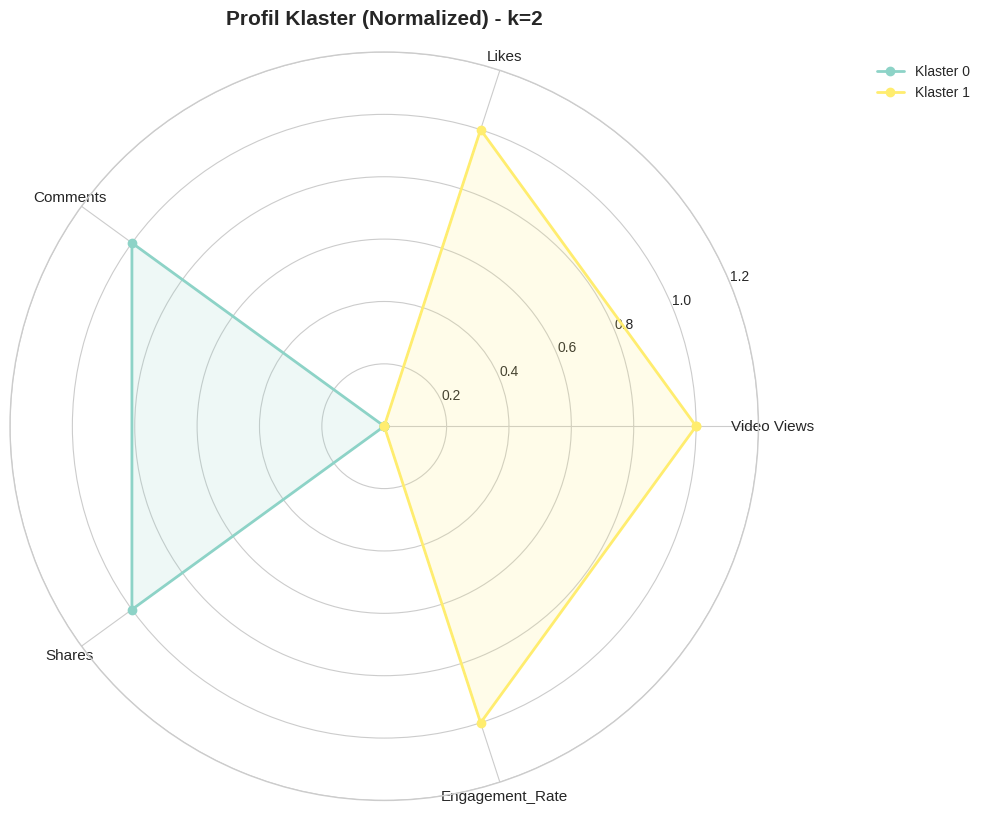

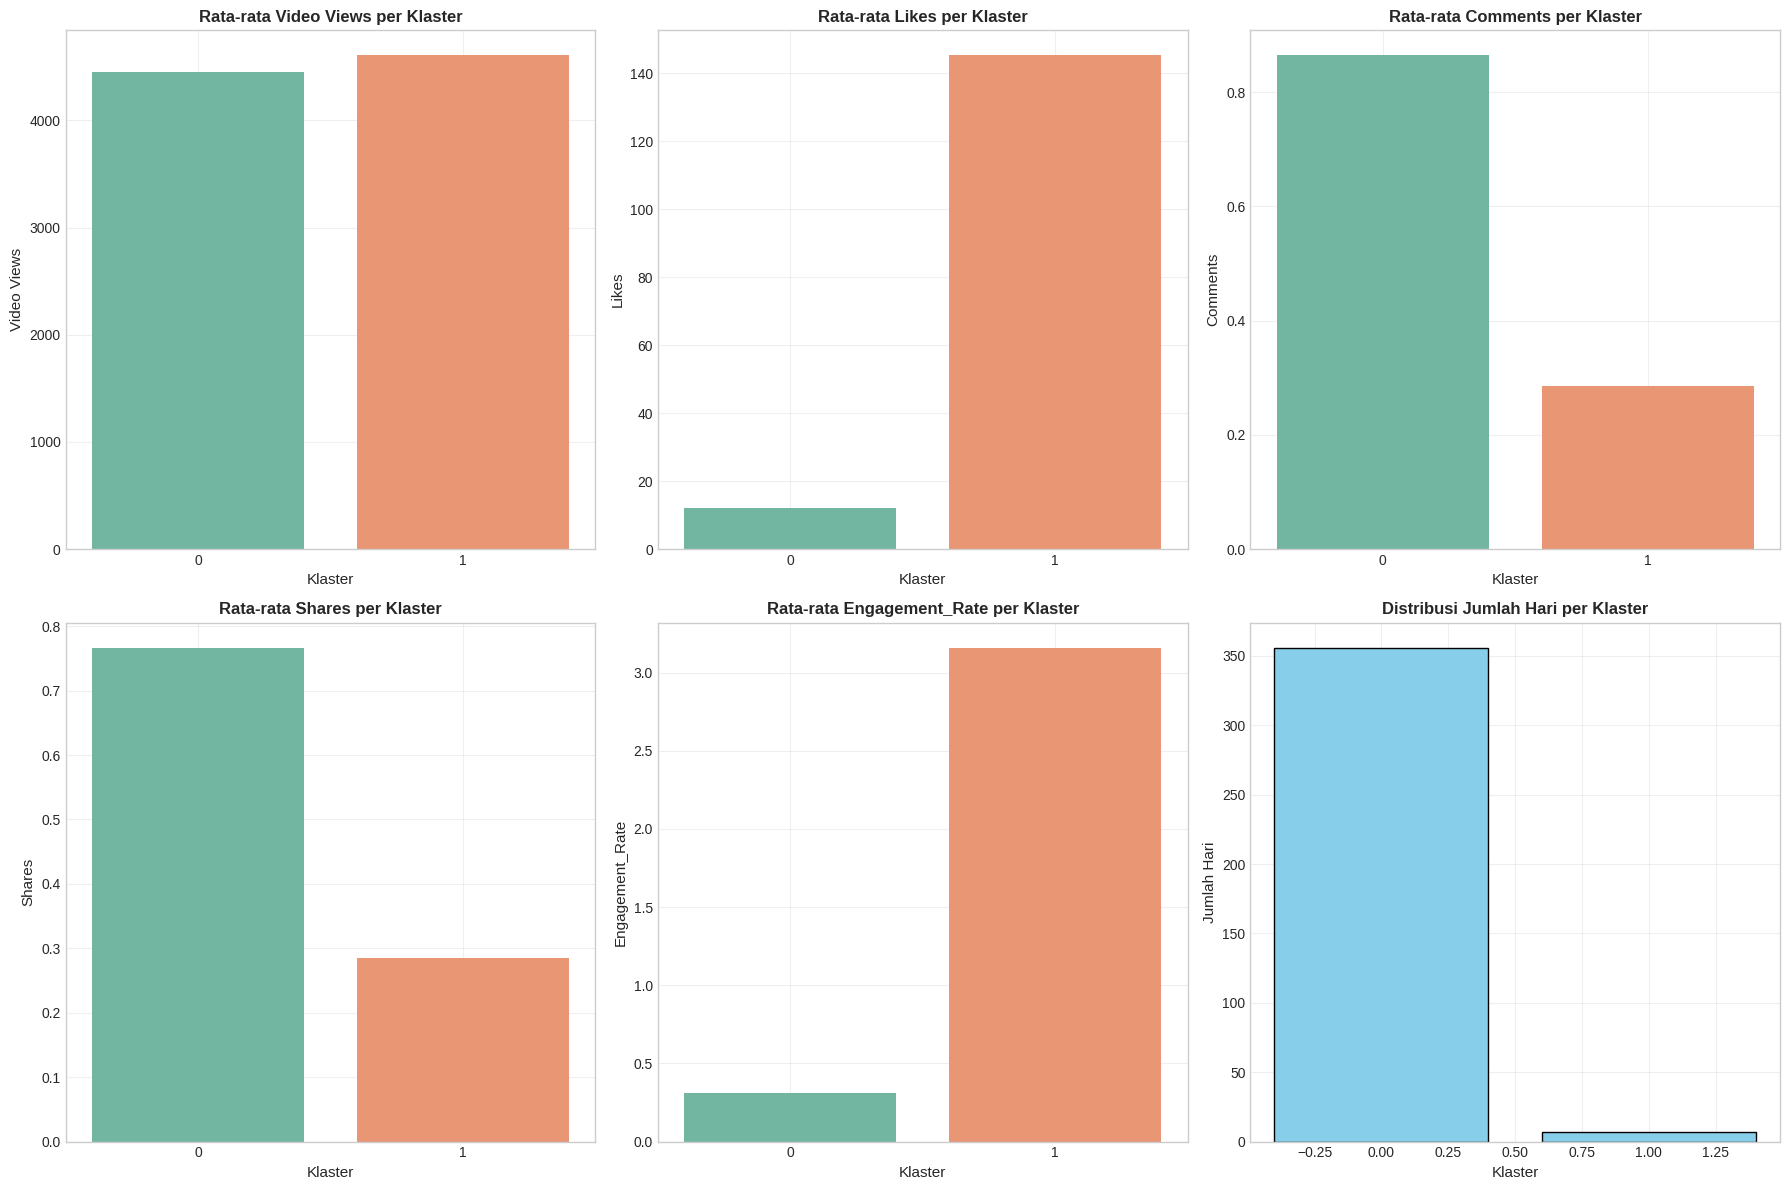

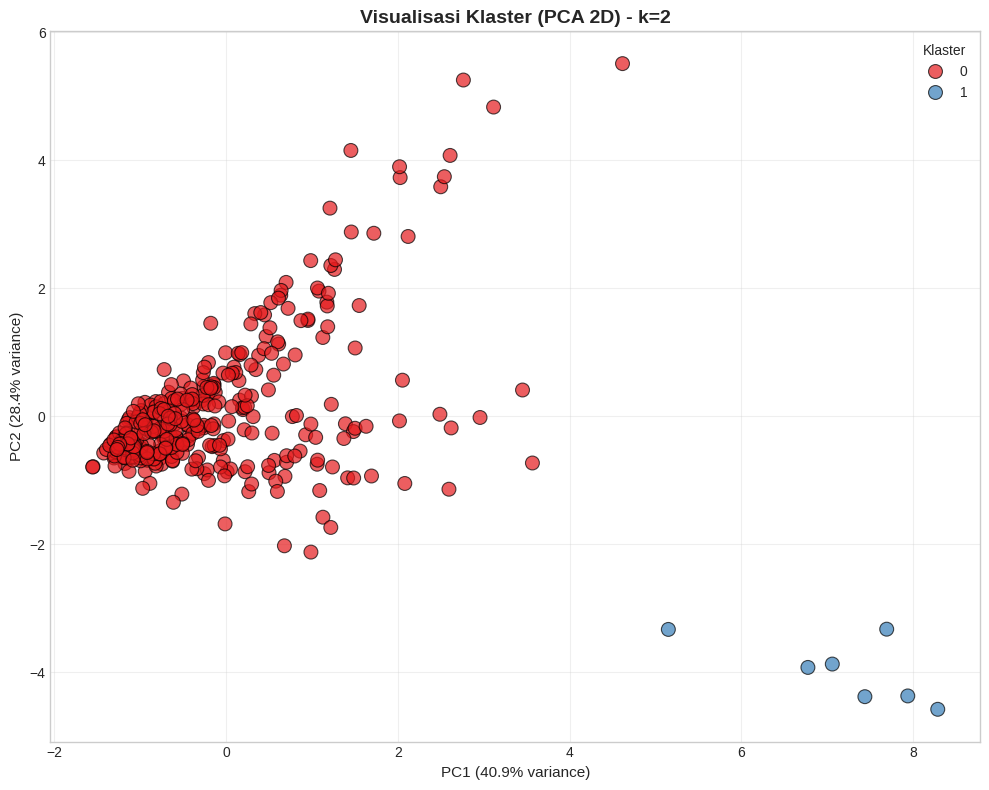

In [16]:
# ============================================================================
# 12. VISUALISASI PROFIL KLASTER
# ============================================================================
print("\n" + "="*80)
print("12. VISUALISASI PROFIL KLASTER")
print("="*80)

# Visualisasi 1: Radar Chart untuk Profil Klaster
from math import pi

def create_radar_chart(data, title):
    """Membuat radar chart untuk membandingkan profil klaster"""
    categories = list(data.columns)
    N = len(categories)

    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

    colors = plt.cm.Set3(np.linspace(0, 1, len(data)))

    for i, (idx, row) in enumerate(data.iterrows()):
        values = row.tolist()
        values += values[:1]
        ax.plot(angles, values, 'o-', linewidth=2, label=f'Klaster {idx}', color=colors[i])
        ax.fill(angles, values, alpha=0.15, color=colors[i])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=11)
    ax.set_ylim(0, max(data.max().max() * 1.2, 1))
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    ax.set_title(title, size=15, fontweight='bold', pad=20)
    ax.grid(True)

    plt.tight_layout()
    plt.savefig('radar_chart_klaster.png', dpi=300, bbox_inches='tight')
    plt.show()

# Normalisasi data untuk radar chart (0-1 scale)
from sklearn.preprocessing import MinMaxScaler
scaler_radar = MinMaxScaler()
cluster_profile_normalized = pd.DataFrame(
    scaler_radar.fit_transform(cluster_profile[features]),
    columns=features,
    index=cluster_profile.index
)

create_radar_chart(cluster_profile_normalized,
                   f'Profil Klaster (Normalized) - k={k_optimal}')

# Visualisasi 2: Bar Chart Perbandingan Fitur
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.barplot(data=df, x='Cluster', y=feature, ax=axes[i], palette='Set2', errorbar=None)
    axes[i].set_title(f'Rata-rata {feature} per Klaster', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Klaster', fontsize=11)
    axes[i].set_ylabel(feature, fontsize=11)
    axes[i].grid(True, alpha=0.3)

# Plot distribusi klaster
cluster_dist = df['Cluster'].value_counts().sort_index()
axes[5].bar(cluster_dist.index, cluster_dist.values, color='skyblue', edgecolor='black')
axes[5].set_title('Distribusi Jumlah Hari per Klaster', fontsize=12, fontweight='bold')
axes[5].set_xlabel('Klaster', fontsize=11)
axes[5].set_ylabel('Jumlah Hari', fontsize=11)
axes[5].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('bar_chart_klaster.png', dpi=300, bbox_inches='tight')
plt.show()

# Visualisasi 3: Scatter Plot (PCA untuk 2D visualization)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
df_pca = pd.DataFrame(pca.fit_transform(df_scaled), columns=['PC1', 'PC2'])
df_pca['Cluster'] = df['Cluster']

plt.figure(figsize=(10, 8))
scatter = sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Cluster',
                          palette='Set1', s=100, alpha=0.7, edgecolor='black')
plt.title(f'Visualisasi Klaster (PCA 2D) - k={k_optimal}', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=11)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=11)
plt.legend(title='Klaster')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('scatter_plot_pca.png', dpi=300, bbox_inches='tight')
plt.show()

In [17]:
# ============================================================================
# 13. INTERPRETASI DAN PEMBERIAN LABEL KLASTER
# ============================================================================
print("\n" + "="*80)
print("13. INTERPRETASI DAN PEMBERIAN LABEL KLASTER")
print("="*80)

# Analisis karakteristik setiap klaster
for cluster in sorted(df['Cluster'].unique()):
    cluster_data = df[df['Cluster'] == cluster]

    print(f"\n{'='*80}")
    print(f"KLASTER {cluster}")
    print(f"{'-'*80}") # Menggunakan '-' untuk garis bawah agar lebih rapi
    print(f"Jumlah hari: {len(cluster_data)} ({len(cluster_data)/len(df)*100:.1f}% dari total data)")
    print(f"\nRata-rata metrik:")
    for feature in features:
        print(f"  - {feature}: {cluster_data[feature].mean():.2f}")

    # Tentukan label berdasarkan ID klaster untuk konsistensi
    if cluster == 0:
        label = "LOW ENGAGEMENT CLUSTER"
        desc = "Klaster ini didominasi oleh konten dengan performa engagement yang cenderung rendah atau normal, ditandai oleh likes, comments, dan shares yang relatif sedikit dibandingkan dengan rata-rata dataset."
    elif cluster == 1:
        label = "HIGH ENGAGEMENT CLUSTER"
        desc = "Klaster ini merepresentasikan konten yang sangat menarik perhatian audiens, ditunjukkan oleh nilai Likes dan Engagement Rate yang sangat tinggi. Menariknya, meskipun likes tinggi, comments dan shares justru cenderung lebih rendah dibandingkan klaster lain, mengindikasikan pola interaksi yang lebih dominan dalam bentuk likes daripada percakapan atau penyebaran."

    print(f"\n📌 LABEL: {label}")
    print(f"💡 Karakteristik: {desc}")



13. INTERPRETASI DAN PEMBERIAN LABEL KLASTER

KLASTER 0
--------------------------------------------------------------------------------
Jumlah hari: 356 (98.1% dari total data)

Rata-rata metrik:
  - Video Views: 4448.12
  - Likes: 12.21
  - Comments: 0.87
  - Shares: 0.77
  - Engagement_Rate: 0.31

📌 LABEL: LOW ENGAGEMENT CLUSTER
💡 Karakteristik: Klaster ini didominasi oleh konten dengan performa engagement yang cenderung rendah atau normal, ditandai oleh likes, comments, dan shares yang relatif sedikit dibandingkan dengan rata-rata dataset.

KLASTER 1
--------------------------------------------------------------------------------
Jumlah hari: 7 (1.9% dari total data)

Rata-rata metrik:
  - Video Views: 4609.00
  - Likes: 145.43
  - Comments: 0.29
  - Shares: 0.29
  - Engagement_Rate: 3.16

📌 LABEL: HIGH ENGAGEMENT CLUSTER
💡 Karakteristik: Klaster ini merepresentasikan konten yang sangat menarik perhatian audiens, ditunjukkan oleh nilai Likes dan Engagement Rate yang sangat tinggi.

In [18]:
# ============================================================================
# 14. REKOMENDASI STRATEGI BERDASARKAN KLASTER
# ============================================================================
print("\n" + "="*80)
print("14. REKOMENDASI STRATEGI PEMASARAN DIGITAL")
print("="*80)

for cluster in sorted(df['Cluster'].unique()):
    cluster_data = df[df['Cluster'] == cluster]
    current_recommendations = []

    # Ambil nilai centroid terstandarisasi untuk klaster ini
    cluster_centroid_scaled = df_centroids_scaled.loc[cluster]

    if cluster == 0:
        category = "LOW ENGAGEMENT CLUSTER"
        current_recommendations.append("Fokus untuk meningkatkan interaksi secara keseluruhan:")

        # Rekomendasi berdasarkan karakteristik Klaster 0 (Low Engagement)
        if cluster_centroid_scaled['Engagement_Rate'] < -0.05: # Engagement Rate di bawah rata-rata
            current_recommendations.append("  - ⬆️ Optimalkan Engagement Rate: Evaluasi daya tarik dan relevansi konten untuk audiens agar memicu interaksi yang lebih tinggi. Pertimbangkan penggunaan elemen pemicu reaksi.")
        if cluster_centroid_scaled['Likes'] < -0.05: # Likes di bawah rata-rata
            current_recommendations.append("  - ⬆️ Peningkatan Likes: Gunakan visual yang lebih menarik, musik yang populer, atau format yang lebih disukai audiens untuk memancing 'suka'.")
        if cluster_centroid_scaled['Comments'] < 0: # Comments di bawah rata-rata
            current_recommendations.append("  - ⬆️ Dorong Komentar: Ajukan pertanyaan di video, buat konten polling, atau respons cepat komentar untuk membangun komunitas.")
        if cluster_centroid_scaled['Shares'] < 0: # Shares di bawah rata-rata
            current_recommendations.append("  - ⬆️ Motivasi Share: Buat konten yang memiliki nilai edukasi, hiburan tinggi, atau 'relateable' agar audiens ingin membagikan kepada temannya.")
        current_recommendations.append("  - 💡 Perbaiki 'Hook' Konten: Pastikan 3-5 detik pertama video mampu menarik perhatian agar audiens tidak segera skip.")

    elif cluster == 1:
        category = "HIGH ENGAGEMENT CLUSTER"
        current_recommendations.append("Fokus untuk mereplikasi dan menskalakan kesuksesan, serta mengatasi kekurangan:")

        # Rekomendasi berdasarkan karakteristik Klaster 1 (High Engagement)
        if cluster_centroid_scaled['Engagement_Rate'] > 1.0 and cluster_centroid_scaled['Likes'] > 1.0: # Engagement Rate & Likes sangat tinggi
            current_recommendations.append("  - ✅ REPLIKASI & SKALA SUKSES: Identifikasi elemen kunci (gaya presentasi, topik, durasi) yang membuat konten ini viral dan tingkatkan frekuensi produksinya.")
            current_recommendations.append("  - ✅ ALOKASI PROMOSI: Pertimbangkan alokasi anggaran promosi untuk konten jenis ini agar jangkauannya semakin luas.")
        if cluster_centroid_scaled['Comments'] < -0.1 or cluster_centroid_scaled['Shares'] < -0.1: # Comments & Shares di bawah rata-rata
            current_recommendations.append("  - 🔄 TINGKATKAN INTERAKSI PASIF KE AKTIF: Meskipun 'likes' tinggi, coba strategi untuk mendorong audiens agar lebih aktif berkomentar dan membagikan (misalnya, 'tag teman', 'bagikan jika setuju').")
        current_recommendations.append("  - 📊 ANALISIS MENDALAM: Lakukan analisis lebih lanjut untuk memahami pemicu engagement tinggi ini secara spesifik (misal: analisis sentimen komentar, tren visual).")

    print(f"\n{'='*80}")
    print(f"KLASTER {cluster} → {category}")
    print(f"{'='*80}")
    print(f"Berdasarkan karakteristik klaster {category} dan teori pemasaran digital yang relevan, beberapa strategi yang dapat dipertimbangkan adalah:")
    for rec in current_recommendations:
        print(rec)


14. REKOMENDASI STRATEGI PEMASARAN DIGITAL

KLASTER 0 → LOW ENGAGEMENT CLUSTER
Berdasarkan karakteristik klaster LOW ENGAGEMENT CLUSTER dan teori pemasaran digital yang relevan, beberapa strategi yang dapat dipertimbangkan adalah:
Fokus untuk meningkatkan interaksi secara keseluruhan:
  - ⬆️ Optimalkan Engagement Rate: Evaluasi daya tarik dan relevansi konten untuk audiens agar memicu interaksi yang lebih tinggi. Pertimbangkan penggunaan elemen pemicu reaksi.
  - ⬆️ Peningkatan Likes: Gunakan visual yang lebih menarik, musik yang populer, atau format yang lebih disukai audiens untuk memancing 'suka'.
  - 💡 Perbaiki 'Hook' Konten: Pastikan 3-5 detik pertama video mampu menarik perhatian agar audiens tidak segera skip.

KLASTER 1 → HIGH ENGAGEMENT CLUSTER
Berdasarkan karakteristik klaster HIGH ENGAGEMENT CLUSTER dan teori pemasaran digital yang relevan, beberapa strategi yang dapat dipertimbangkan adalah:
Fokus untuk mereplikasi dan menskalakan kesuksesan, serta mengatasi kekurangan:
  

In [19]:
# ============================================================================
# 14. SIMPAN HASIL ANALISIS
# ============================================================================
print("\n" + "="*80)
print("14. MENYIMPAN HASIL ANALISIS")
print("="*80)

# Simpan dataframe dengan label klaster
df.to_csv('hasil_clustering_lengkap.csv', index=False)
print("✓ Data lengkap dengan label klaster: 'hasil_clustering_lengkap.csv'")

# Simpan dataframe gabungan tanpa kolom klaster (untuk lampiran)
df.drop(columns=['Cluster']).to_csv('merged_data_for_analysis.csv', index=False)
print("✓ Dataset gabungan untuk analisis: 'merged_data_for_analysis.csv'")

# Simpan ringkasan statistik
summary_stats = {
    'Total_Observasi': [len(df)],
    'Periode_Data': [f"{df['Date'].min()} - {df['Date'].max()}"],
    'Jumlah_Klaster': [k_optimal],
    'Silhouette_Score': [final_silhouette],
    'Davies_Bouldin_Index': [final_davies_bouldin],
    'Calinski_Harabasz_Index': [final_calinski_harabasz],
    'Avg_Engagement_Rate': [df['Engagement_Rate'].mean()],
    'Avg_Video_Views': [df['Video Views'].mean()]
}

df_summary = pd.DataFrame(summary_stats)
df_summary.to_csv('ringkasan_hasil.csv', index=False)
print("✓ Ringkasan hasil: 'ringkasan_hasil.csv'")

print("\n" + "="*80)
print("🎉 ANALISIS SELESAI!")
print("="*80)
print("\nFile yang dihasilkan:")
print("  1. profil_klaster.csv")
print("  2. hasil_clustering_lengkap.csv")
print("  3. merged_data_for_analysis.csv") # Added this line
print("  4. ringkasan_hasil.csv")
print("  5. evaluasi_k_optimal.png")
print("  6. radar_chart_klaster.png")
print("  7. bar_chart_klaster.png")
print("  8. scatter_plot_pca.png")
print("\n" + "="*80)


14. MENYIMPAN HASIL ANALISIS
✓ Data lengkap dengan label klaster: 'hasil_clustering_lengkap.csv'
✓ Dataset gabungan untuk analisis: 'merged_data_for_analysis.csv'
✓ Ringkasan hasil: 'ringkasan_hasil.csv'

🎉 ANALISIS SELESAI!

File yang dihasilkan:
  1. profil_klaster.csv
  2. hasil_clustering_lengkap.csv
  3. merged_data_for_analysis.csv
  4. ringkasan_hasil.csv
  5. evaluasi_k_optimal.png
  6. radar_chart_klaster.png
  7. bar_chart_klaster.png
  8. scatter_plot_pca.png

